In [1]:
# Collection library, runs in terminal because of "!"
!pip install bing-image-downloader
# Not used for this projcet. Because of not enough data.
# Instead of, used this dataset: https://www.kaggle.com/datasets/ashwingupta3012/human-faces

### Upload `haarcascade_frontalface_default.xml`
Please upload the `haarcascade_frontalface_default.xml` file. This file is essential for face detection.

# 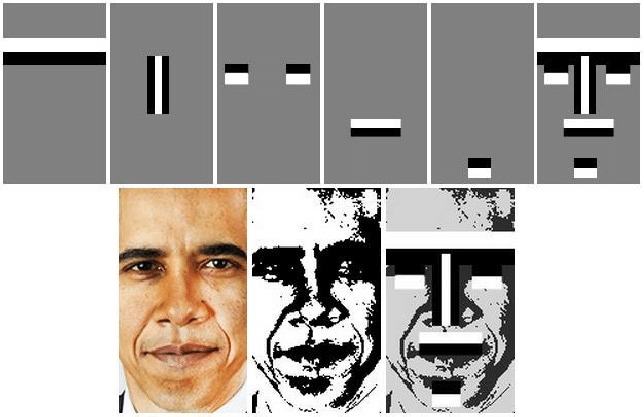

In [2]:
!pip install opencv-python tqdm numpy

In [4]:
# Let's use a dataset from Kaggle, because bing image downloader does not worked well
# For extracting faces,use the "classifier".It has features itself for detecting face from image.
# https://github.com/kipr/opencv/blob/master/data/haarcascades/haarcascade_frontalface_default.xml
# Download the xml document. Then uplod into Colab.
# You may think haar-like features as CNN filters. Each filters corresponds to a different feature.

import cv2
face_cascade=cv2.CascadeClassifier('haarcascade_frontalface_default.xml')

# Access the images.
import os
from  tqdm import tqdm
import numpy as np

shape=64 # After resizing, the image shape that only contains "face".
channel=3
data=[]
directory="directory"
for pic in tqdm(os.listdir(directory)):
  pic=os.path.join(directory,pic)
  img=cv2.imread(pic,cv2.IMREAD_COLOR)

  if(img is not None): # Face detection work with non-colored images.
    gray_image=cv2.cvtColor(img,cv2.COLOR_RGB2GRAY)
    # Parameters for detecting face
    # 'minNeighbors=8' for how many neighbor rectangle do we want for labeling the are to "face". You can change it as you want.
    faces=face_cascade.detectMultiScale(gray_image,1.25, 8)

    for f in faces:
      x,y,w,h= [ v for v in f] # w for 'width', h for 'height'
      face_crop=img[y:y+h,x:x+w] # For opencv , first write Y then write X
      resized=cv2.resize(face_crop,(shape,shape)) # Neural networks mostly works with squares. You are not obliged to use.
      data.append(resized)






100%|██████████| 7219/7219 [03:35<00:00, 33.42it/s]


In [7]:
%%capture
!pip install matplotlib

<function matplotlib.pyplot.show(close=None, block=None)>

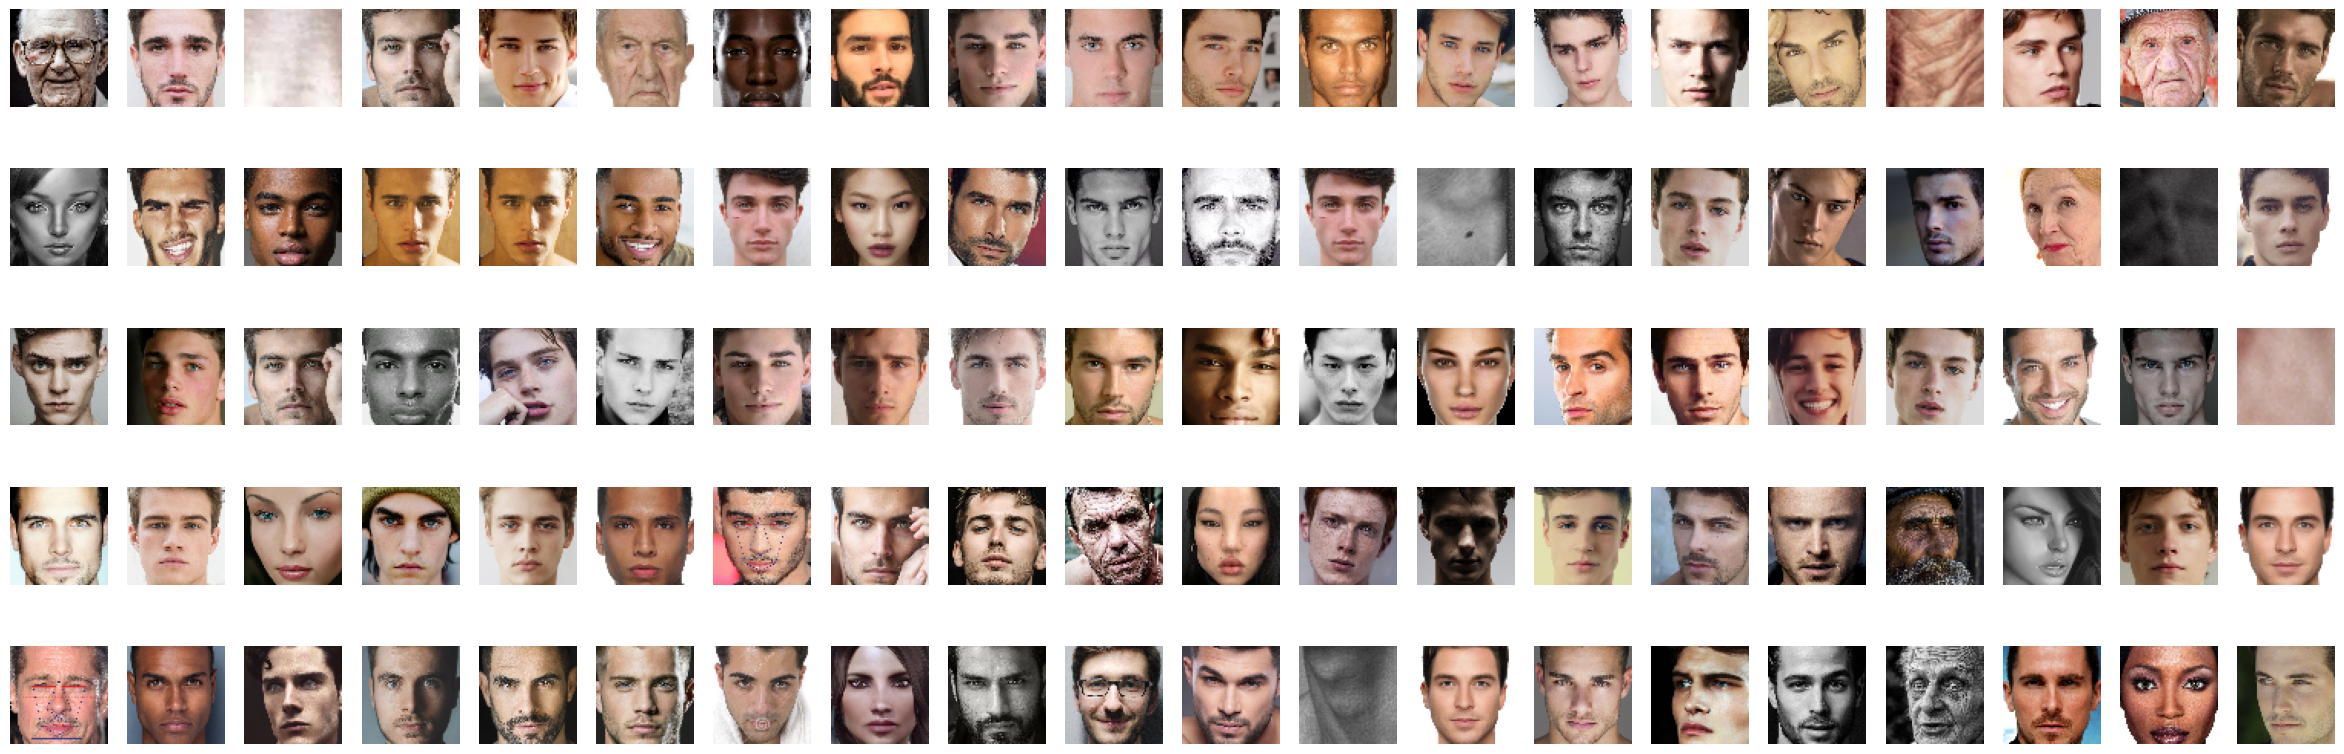

In [15]:

import matplotlib.pyplot as plt

fig=plt.figure(figsize=(30,10))
for i in range(100):
  plt.subplot(5,20,i+1)
  plt.imshow(cv2.cvtColor(data[i],cv2.COLOR_BGR2RGB))
  plt.axis('off')

plt.show

In [18]:
import numpy  as np
# Converting numpy array because it is fast and runs directly in RAM.
data=np.array(data).reshape(-1,shape,shape,channel).astype('float32') # -1 stands for scalability.
#It basicly means "I will convert the data[0] to number of images.Even if don't know the size."
data=(data-127.5) / 127.5 # Normalizing array. 
# [0,255] --> [-1,1]

In [19]:
data.shape  #Our data contains 5082 image, 64x64 and RGB 

(5082, 64, 64, 3)

In [20]:
import pickle
# Save the "data numpy array" as pkl. 
# Saving as 'wb' b for "binary".
pickle.dump(data,open("faces.pkl","wb"))

# Upload data

# data = pickle.load("faces.pkl")


*Prepared data successfully.Then run this data through GAN.* 

In [21]:
%%capture
!pip install tensorflow


In [22]:
import tensorflow as tf

# Converting data to tensor.
# Slice the data into batches. So we can utilize the GPUs parallel computation.
BATCH_SIZE= 256
data=tf.data.Dataset.from_tensor_slices(data).batch(BATCH_SIZE)

![alt text](0_eeYJwyNgOzn4smHx.jpg)

In [29]:
from tensorflow.keras  import layers 
# This cell contains implementing Generator network
# Generator network,generates images from noise.

NOISE_SIZE= 100 # Starting numbers.Randomly. They will convert into 4*4*512 in future.
# It is a hyperparameter

initializer=tf.random_normal_initializer(0.,0.02) # Mean,variation

gen=tf.keras.Sequential() # Layers into a single stack

gen.add(layers.Dense(4*4*512,use_bias=False, input_shape=(NOISE_SIZE,)))
# 4 width 4 height 512 number of generations 
gen.add(layers.BatchNormalization()) # For generalization
gen.add(layers.LeakyReLU()) # Learns negatives also

gen.add(layers.Reshape((4,4,512))) # For convolution 

gen.add(layers.Conv2DTranspose(512,(3,3), strides=(1,1),padding='same',kernel_initializer=initializer,use_bias=False))
 # Not using bias because of computational cost.       
gen.add(layers.BatchNormalization()) 
gen.add(layers.LeakyReLU()) 

gen.add(layers.Conv2DTranspose(256,(5,5), strides=(2,2),padding='same',kernel_initializer=initializer,use_bias=False))
gen.add(layers.BatchNormalization()) 
gen.add(layers.LeakyReLU()) 

gen.add(layers.Conv2DTranspose(64,(5,5), strides=(2,2),padding='same',kernel_initializer=initializer,use_bias=False))
gen.add(layers.BatchNormalization()) 
gen.add(layers.LeakyReLU()) 

gen.add(layers.Conv2DTranspose(64,(5,5), strides=(2,2),padding='same',kernel_initializer=initializer,use_bias=False))
gen.add(layers.BatchNormalization()) 
gen.add(layers.LeakyReLU()) 

gen.add(layers.Conv2DTranspose(channel,(5,5),strides=(2,2),padding='same',kernel_initializer=initializer,use_bias=False,activation="tanh"))
# Tanh range (-1,1) 
# It more utility for computations
  




tf.Tensor(
[[-0.28549635  0.5812489   0.8707967  -0.8542026  -0.72273654 -1.3389639
   0.10132904 -0.7338658   0.56990784 -0.9657927  -0.11813052 -1.3793211
   1.3921988   0.35558993  1.833462   -1.0126851   0.12918203 -0.99200773
  -0.447613    0.8143273  -0.08642157  0.13270642  0.13550384 -0.23734133
  -0.60523945  0.26019403 -1.0960331  -0.2542369   0.54791534  2.2505407
   0.04635565 -0.0701554   1.1027724   1.7031116   0.3574635  -0.6250404
   1.036538   -0.2910004   1.569508    0.2831379   1.4424493   0.4577031
   1.0951133   0.06960683  0.14901389  2.297089    0.9899047   0.10545036
   1.0342791  -0.7239433  -1.3196623  -2.4608035   0.6613796   2.7239578
  -0.72065234  0.5791978  -0.8161306  -0.17204817 -0.8713109  -0.9217302
  -0.9672054   0.10080311 -0.7962274   0.78048176 -0.07716931 -0.13720241
  -1.5370619  -0.48207363 -0.3292826   0.5587183  -0.5347854  -1.6736522
   0.432933    0.6743883  -1.374843    0.36500263  0.70394427 -1.471191
  -0.6370718  -1.2878885  -1.6343895 

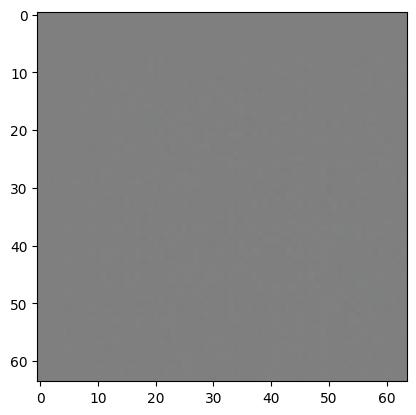

In [26]:
noise=tf.random.normal([1,100])
print(noise)
test_image= gen(noise,training=False)
plt.imshow(cv2.cvtColor((test_image[0]*127.5 + 127.5).numpy().reshape(shape,shape,channel).astype('uint8'),cv2.COLOR_BGR2RGB))

In [ ]:
%%capture
%pip uninstall opencv-python opencv-contrib-python opencv-python-headless -y

In [28]:
%%capture

%pip install opencv-contrib-python

## This cell contains Discriminator network implementation

In [30]:
dis = tf.keras.Sequential()

dis.add(layers.Conv2D(64, (3, 3), strides=(2, 2), padding='same', input_shape=[shape, shape, channel], kernel_initializer=initializer, use_bias=False))
dis.add(layers.BatchNormalization())
dis.add(layers.LeakyReLU())
dis.add(layers.Dropout(0.2))

dis.add(layers.Conv2D(128, (3, 3), strides=(2, 2), padding='same', kernel_initializer=initializer, use_bias=False))
dis.add(layers.BatchNormalization())
dis.add(layers.LeakyReLU())
dis.add(layers.Dropout(0.2))

dis.add(layers.Conv2D(256, (3, 3), strides=(2, 2), padding='same', kernel_initializer=initializer, use_bias=False))
dis.add(layers.BatchNormalization())
dis.add(layers.LeakyReLU())
dis.add(layers.Dropout(0.2))

dis.add(layers.Conv2D(512, (3, 3), strides=(2, 2), padding='same', kernel_initializer=initializer, use_bias=False))
dis.add(layers.BatchNormalization())
dis.add(layers.LeakyReLU())
dis.add(layers.Dropout(0.2))

dis.add(layers.Flatten())


dis.add(layers.Dense(1)) 

c:\Users\ASUS\Desktop\Projects\OLD\HumanFaces\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [31]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)
def dis_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    
    
    total_loss = real_loss + fake_loss
    return total_loss



def gen_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

In [32]:
gen_opt = tf.keras.optimizers.Adam(1e-4)
dis_opt = tf.keras.optimizers.Adam(1e-4)

In [33]:
@tf.function
def train_step(images):
    # Create NOISE same as number of batch size.
    noise = tf.random.normal([BATCH_SIZE, NOISE_SIZE])

    
    with tf.GradientTape() as gen_tape, tf.GradientTape() as dis_tape:
        generated_images = gen(noise, training=True)

        real_output = dis(images, training=True)

        fake_output = dis(generated_images, training=True)

        gen_loss_val = gen_loss(fake_output)
        dis_loss_val = dis_loss(real_output, fake_output)

    grad_gen = gen_tape.gradient(gen_loss_val, gen.trainable_variables)
    grad_dis = dis_tape.gradient(dis_loss_val, dis.trainable_variables)

    gen_opt.apply_gradients(zip(grad_gen, gen.trainable_variables))
    dis_opt.apply_gradients(zip(grad_dis, dis.trainable_variables))

In [34]:
from IPython import display 

EPOCHS = 1000 # When training,it means how many times will we pass the data.

seed = tf.random.normal([25, NOISE_SIZE]) 

for epoch in range(EPOCHS):
    
    for image_batch in data:
        train_step(image_batch)

    predictions = gen(seed, training=False)

    fig = plt.figure(figsize=(10,10))

    for i in range(predictions.shape[0]):
        plt.subplot(5, 5, i+1)
        plt.imshow(cv2.cvtColor((predictions[i]* 127.5 + 127.5).numpy().reshape(shape,shape,channel).astype('uint8') , cv2.COLOR_BGR2RGB))
        plt.axis('off')

    plt.show()
    print('epoch',epoch)

    data.shuffle(10000)

    display.clear_output(wait=True)

KeyboardInterrupt: 


It utilizes CPU. Not efficient. Interrupt code cell immediately

tf.Tensor([[-4.8686028]], shape=(1, 1), dtype=float32)


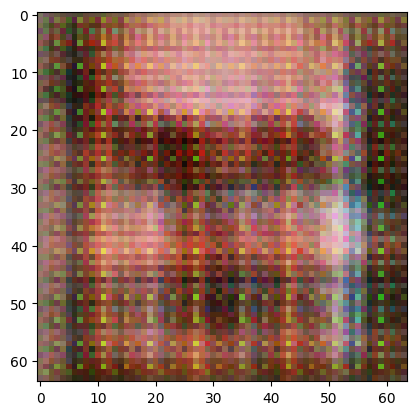

In [50]:
noise=tf.random.normal([1,100])
test_image=gen(noise,training=False)
plt.imshow(cv2.cvtColor((test_image[0]*127.5 + 127.5).numpy().reshape(shape,shape,channel).astype("uint8"),cv2.COLOR_BGR2RGB))
print(dis(test_image))